# Pregunta de negocio: disponibilidad media por ciudad

**Pregunta:** ¿Cuál es la disponibilidad media de los alojamientos turísticos
en los diferentes plazos (30, 60, 90 y 365 d?as) en cada ciudad?

El análisis parte del proceso de transformación del dataset limpio. Se mantiene
un enfoque sencillo y orientado a negocio: primero se filtran alojamientos con
disponibilidad real, después se calculan totales, medias, porcentajes y un test
para comprobar si hay diferencias significativas entre los cuatro plazos.

## 1. Librerías y rutas

Se usan rutas relativas para que el notebook funcione al abrir la carpeta del
proyecto en VS Code.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
def encontrar_raiz_proyecto():
    "Encuentra la carpeta que contiene data y results."
    actual = Path.cwd()
    carpetas = [actual] + list(actual.parents)

    for carpeta in carpetas:
        tiene_data = (carpeta / "data").exists()
        tiene_results = (carpeta / "results").exists()

        if tiene_data and tiene_results:
            return carpeta

    raise FileNotFoundError("No se encontr? la estructura del proyecto.")


raiz_proyecto = encontrar_raiz_proyecto()
ruta_datos = raiz_proyecto / "data" / "clean_dataset_29_06_2026.csv"
ruta_resultados = raiz_proyecto / "results"
ruta_resultados.mkdir(exist_ok=True)

print("Estructura del proyecto encontrada correctamente.")

Estructura del proyecto encontrada correctamente.


## 2. Carga y transformaci?n base

Se replica la l?gica principal del notebook de transformación: trabajar sobre
una copia, crear variables binarias y mantener las columnas de disponibilidad.

In [3]:
df_original = pd.read_csv(ruta_datos, low_memory=False)
df = df_original.copy()

print("Filas y columnas iniciales:", df.shape)
df.head()

Filas y columnas iniciales: (6733, 35)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price_€,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,13707226,"Remarkable Value, Unbeatable Location",A spacious double bedroom with a balcony. It's...,80008404,el Barri G�tic,Ciutat Vella,Private room,2,4.0,1.0,2.0,"TV,Internet,Wireless Internet,Air conditioning...",600.0,28,1125,NaN,30,60,90,180,13,2016-08-04,2016-09-23,940.0,100.0,90.0,90.0,90.0,90.0,90.0,VERDADERO,25.0,spain,barcelona,2017-01-04
1,13011987,"Lovely flat in Barcelona, 10' from the city ce...","Ideal for couples, located in a quiet and safe...",31321818,Sant Mart� de Proven�als,Sant Mart�,Entire home/apt,2,1.0,1.0,1.0,"TV,Wireless Internet,Air conditioning,Wheelcha...",650.0,2,14,NaN,0,0,0,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FALSO,NaN,spain,barcelona,2017-01-04
2,14999488,Habitaci�n doble en bonito apartamento,Piso grande y bonito de 90 m2. Tranquilo y por...,7093663,el Camp d'en Grassot i Gr�cia Nova,Gr�cia,Private room,2,1.0,1.0,1.0,"Internet,Wireless Internet,Air conditioning,Ki...",250.0,1,30,NaN,4,18,48,104,2,2016-10-06,2016-12-27,900.0,100.0,100.0,100.0,90.0,100.0,100.0,VERDADERO,65.0,spain,barcelona,2017-01-04
3,6547870,Bella Vista. N� de registro: HUTB005799,Bella Vista es un apartamento �nico en Barcelo...,34249903,el Baix Guinard�,Horta-Guinard�,Entire home/apt,7,1.0,3.0,4.0,"TV,Internet,Wireless Internet,Air conditioning...",750.0,4,1125,NaN,30,45,47,238,25,2015-10-10,2017-01-05,860.0,90.0,80.0,90.0,90.0,90.0,90.0,VERDADERO,165.0,spain,barcelona,2017-01-04
4,15253506,Casa de Andrea,"My house is very big, from the twenties. I onl...",17925327,Sants,Sants-Montju�c,Entire home/apt,14,2.0,5.0,14.0,"Internet,Wireless Internet,Kitchen,Buzzer/wire...",3150.0,1,1125,NaN,11,36,65,338,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FALSO,NaN,spain,barcelona,2017-01-04


In [4]:
df["has_availability_numeric"] = (
    df["has_availability"]
    .map({"VERDADERO": 1, "FALSO": 0})
    .astype("Int64")
)

plazos = {
    "30": 30,
    "60": 60,
    "90": 90,
    "365": 365,
}

for sufijo, total_dias in plazos.items():
    col_disp = f"availability_{sufijo}"
    col_ocup = f"occupancy_{sufijo}"
    col_tasa = f"occupancy_rate_{sufijo}"

    df[col_ocup] = total_dias - df[col_disp]
    df[col_tasa] = (df[col_ocup] / total_dias * 100).round(2)

print(df["has_availability_numeric"].value_counts(dropna=False))

has_availability_numeric
1       6199
<NA>     534
Name: count, dtype: Int64


## 3. Filtro de disponibilidad real

Para responder a la pregunta se usan solo alojamientos con disponibilidad real.
Tambi?n se eliminan nulos en ciudad y en los cuatro plazos de disponibilidad.

In [5]:
columnas_disponibilidad = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
]

columnas_analisis = [
    "apartment_id",
    "city",
    "has_availability_numeric",
] + columnas_disponibilidad

alojamientos = df[columnas_analisis].copy()
alojamientos = alojamientos[
    alojamientos["has_availability_numeric"] == 1
].copy()

alojamientos = alojamientos.dropna(
    subset=["city"] + columnas_disponibilidad
)

for columna in columnas_disponibilidad:
    alojamientos[columna] = pd.to_numeric(
        alojamientos[columna],
        errors="coerce",
    )

alojamientos = alojamientos.dropna(subset=columnas_disponibilidad)
alojamientos["city"] = alojamientos["city"].str.strip().str.lower()

print("Alojamientos con disponibilidad real:", len(alojamientos))

Alojamientos con disponibilidad real: 6199


In [6]:
mascara_valida = pd.Series(True, index=alojamientos.index)

for sufijo, total_dias in plazos.items():
    columna = f"availability_{sufijo}"
    mascara_valida = mascara_valida & alojamientos[columna].between(
        0,
        total_dias,
    )

alojamientos = alojamientos[mascara_valida].copy()

print("Filas despu?s de validar rangos:", len(alojamientos))

Filas despu?s de validar rangos: 6199


## 4. Total de alojamientos disponibles por ciudad

Esta tabla muestra el n?mero total de alojamientos con disponibilidad real en
cada ciudad. También calcula el porcentaje que representa cada ciudad sobre el
total de alojamientos disponibles analizados.


In [7]:
total_por_ciudad = (
    alojamientos
    .groupby("city", as_index=False)
    .agg(
        total_alojamientos_disponibles=("apartment_id", "nunique")
    )
)

total_disponibles = (
    total_por_ciudad["total_alojamientos_disponibles"].sum()
)

total_por_ciudad["porcentaje_sobre_total"] = (
    total_por_ciudad["total_alojamientos_disponibles"]
    / total_disponibles
    * 100
).round(2)

total_por_ciudad = total_por_ciudad.sort_values(
    "total_alojamientos_disponibles",
    ascending=False,
)

total_por_ciudad


,city,total_alojamientos_disponibles,porcentaje_sobre_total
0,barcelona,1630,26.29
2,madrid,1311,21.15
1,girona,1085,17.50
4,mallorca,1058,17.07
6,sevilla,341,5.50
3,malaga,339,5.47
7,valencia,297,4.79
5,menorca,138,2.23


## 5. Datos en formato largo

Se crea una fila por alojamiento, ciudad y plazo. Así se pueden comparar los
cuatro periodos en una sola tabla y en los gráficos.

In [8]:
disponibilidad_larga = alojamientos.melt(
    id_vars=["apartment_id", "city"],
    value_vars=columnas_disponibilidad,
    var_name="periodo_columna",
    value_name="dias_disponibles",
)

disponibilidad_larga["periodo"] = (
    disponibilidad_larga["periodo_columna"]
    .str.extract(r"(\d+)")
    .astype(int)
)

disponibilidad_larga["disponibilidad_pct"] = (
    disponibilidad_larga["dias_disponibles"]
    / disponibilidad_larga["periodo"]
    * 100
)

disponibilidad_larga.head()

,apartment_id,city,periodo_columna,dias_disponibles,periodo,disponibilidad_pct
0,19202541,barcelona,availability_30,0,30,0.000000
1,4344409,barcelona,availability_30,6,30,20.000000
2,7496805,barcelona,availability_30,0,30,0.000000
3,16106373,barcelona,availability_30,29,30,96.666667
4,1420428,barcelona,availability_30,4,30,13.333333


## 6. Promedios y porcentajes por ciudad

La tabla resume la disponibilidad media por ciudad y periodo. Además, incluye
el número de alojamientos con al menos un día disponible en cada plazo.

In [9]:
resumen = (
    disponibilidad_larga
    .groupby(["city", "periodo"], as_index=False)
    .agg(
        alojamientos_analizados=("apartment_id", "nunique"),
        alojamientos_con_dias=(
            "dias_disponibles",
            lambda serie: (serie > 0).sum(),
        ),
        promedio_dias=("dias_disponibles", "mean"),
        promedio_pct=("disponibilidad_pct", "mean"),
    )
)

resumen = resumen.merge(total_por_ciudad, on="city", how="left")
resumen["pct_alojamientos_con_dias"] = (
    resumen["alojamientos_con_dias"]
    / resumen["total_alojamientos_disponibles"]
    * 100
)

columnas_redondeo = [
    "promedio_dias",
    "promedio_pct",
    "pct_alojamientos_con_dias",
]

resumen[columnas_redondeo] = resumen[columnas_redondeo].round(2)
resumen.sort_values(["periodo", "promedio_dias"])

,city,periodo,alojamientos_analizados,alojamientos_con_dias,promedio_dias,promedio_pct,total_alojamientos_disponibles,porcentaje_sobre_total,pct_alojamientos_con_dias
8,madrid,30,1311,851,10.24,34.13,1311,21.15,64.91
0,barcelona,30,1630,1118,11.40,38.00,1630,26.29,68.59
12,malaga,30,339,256,12.14,40.48,339,5.47,75.52
16,mallorca,30,1058,774,13.25,44.16,1058,17.07,73.16
28,valencia,30,297,219,13.59,45.30,297,4.79,73.74
24,sevilla,30,341,289,14.06,46.86,341,5.50,84.75
4,girona,30,1085,745,14.59,48.62,1085,17.50,68.66
20,menorca,30,138,93,14.99,49.95,138,2.23,67.39
9,madrid,60,1311,915,23.82,39.71,1311,21.15,69.79
1,barcelona,60,1630,1214,26.11,43.51,1630,26.29,74.48


In [10]:
tabla_dias = resumen.pivot(
    index="city",
    columns="periodo",
    values="promedio_dias",
)

tabla_dias

periodo,30,60,90,365
city,,,,
barcelona,11.40,26.11,43.03,179.11
girona,14.59,31.27,48.35,195.07
madrid,10.24,23.82,39.43,159.93
malaga,12.14,28.43,47.13,202.65
mallorca,13.25,28.37,44.70,209.50
menorca,14.99,30.88,47.54,199.49
sevilla,14.06,30.92,50.05,199.75
valencia,13.59,29.73,47.72,183.75


In [11]:
tabla_porcentaje = resumen.pivot(
    index="city",
    columns="periodo",
    values="promedio_pct",
)

tabla_porcentaje

periodo,30,60,90,365
city,,,,
barcelona,38.00,43.51,47.82,49.07
girona,48.62,52.12,53.72,53.44
madrid,34.13,39.71,43.81,43.82
malaga,40.48,47.38,52.36,55.52
mallorca,44.16,47.28,49.67,57.40
menorca,49.95,51.46,52.83,54.66
sevilla,46.86,51.53,55.61,54.73
valencia,45.30,49.55,53.02,50.34


## 7. Test promedio: diferencia entre los cuatro plazos

Como los plazos tienen escalas distintas, el test se aplica sobre el porcentaje
de disponibilidad. Se calcula un estad?stico tipo ANOVA y un p-valor por
permutación para comprobar si las medias de los cuatro periodos son diferentes.

- Hipótesis nula: las medias de disponibilidad son iguales en los 4 plazos.
- Hipótesis alternativa: al menos una media es diferente.
- Nivel de significación usado: 0.05.

In [12]:
def calcular_f_anova(valores, etiquetas, periodos):
    "Calcula un estad?stico F para comparar medias."
    media_global = valores.mean()
    suma_entre = 0
    suma_dentro = 0

    for periodo in periodos:
        grupo = valores[etiquetas == periodo]
        media_grupo = grupo.mean()
        suma_entre += len(grupo) * (media_grupo - media_global) ** 2
        suma_dentro += ((grupo - media_grupo) ** 2).sum()

    grados_entre = len(periodos) - 1
    grados_dentro = len(valores) - len(periodos)

    return (suma_entre / grados_entre) / (suma_dentro / grados_dentro)


def test_permutacion_anova(datos, n_permutaciones=1000):
    "Devuelve F y p-valor por permutaci?n."
    valores = datos["disponibilidad_pct"].to_numpy()
    etiquetas = datos["periodo"].to_numpy()
    periodos = np.array([30, 60, 90, 365])
    f_observado = calcular_f_anova(valores, etiquetas, periodos)
    rng = np.random.default_rng(42)
    conteo = 0
    etiquetas_perm = etiquetas.copy()

    for _ in range(n_permutaciones):
        rng.shuffle(etiquetas_perm)
        f_perm = calcular_f_anova(valores, etiquetas_perm, periodos)
        conteo += f_perm >= f_observado

    p_valor = (conteo + 1) / (n_permutaciones + 1)
    return f_observado, p_valor


estadistico_f, p_valor = test_permutacion_anova(disponibilidad_larga)

resultado_global = pd.DataFrame(
    {
        "test": ["ANOVA por permutaci?n"],
        "estadistico_f": [round(estadistico_f, 4)],
        "p_valor": [round(p_valor, 6)],
        "diferencia_significativa": [p_valor < 0.05],
    }
)

resultado_global

,test,estadistico_f,p_valor,diferencia_significativa
0,ANOVA por permutaci?n,81.3532,0.000999,True


In [13]:
resultados_ciudad = []

for ciudad, datos_ciudad in disponibilidad_larga.groupby("city"):
    estadistico_f, p_valor = test_permutacion_anova(
        datos_ciudad,
        n_permutaciones=500,
    )

    resultados_ciudad.append(
        {
            "city": ciudad,
            "estadistico_f": round(estadistico_f, 4),
            "p_valor": round(p_valor, 6),
            "diferencia_significativa": p_valor < 0.05,
        }
    )

resultado_test_ciudad = pd.DataFrame(resultados_ciudad)
resultado_test_ciudad.sort_values("p_valor")

,city,estadistico_f,p_valor,diferencia_significativa
0,barcelona,28.9088,0.001996,True
2,madrid,20.3513,0.001996,True
3,malaga,12.5147,0.001996,True
4,mallorca,25.8937,0.001996,True
1,girona,3.9788,0.003992,True
6,sevilla,4.8441,0.003992,True
7,valencia,2.1986,0.085828,False
5,menorca,0.3412,0.794411,False


## 8. Gráfico 1: disponibilidad media en porcentaje

El gr?fico apilado permite comparar el porcentaje medio de disponibilidad de
cada ciudad en los cuatro plazos.

In [14]:
tabla_grafico_pct = resumen.pivot(
    index="city",
    columns="periodo",
    values="promedio_pct",
)

orden_ciudades = (
    tabla_grafico_pct.sum(axis=1)
    .sort_values(ascending=False)
    .index
)

tabla_grafico_pct = tabla_grafico_pct.loc[
    orden_ciudades,
    [30, 60, 90, 365],
]

tabla_grafico_pct

periodo,30,60,90,365
city,,,,
menorca,49.95,51.46,52.83,54.66
sevilla,46.86,51.53,55.61,54.73
girona,48.62,52.12,53.72,53.44
mallorca,44.16,47.28,49.67,57.40
valencia,45.30,49.55,53.02,50.34
malaga,40.48,47.38,52.36,55.52
barcelona,38.00,43.51,47.82,49.07
madrid,34.13,39.71,43.81,43.82


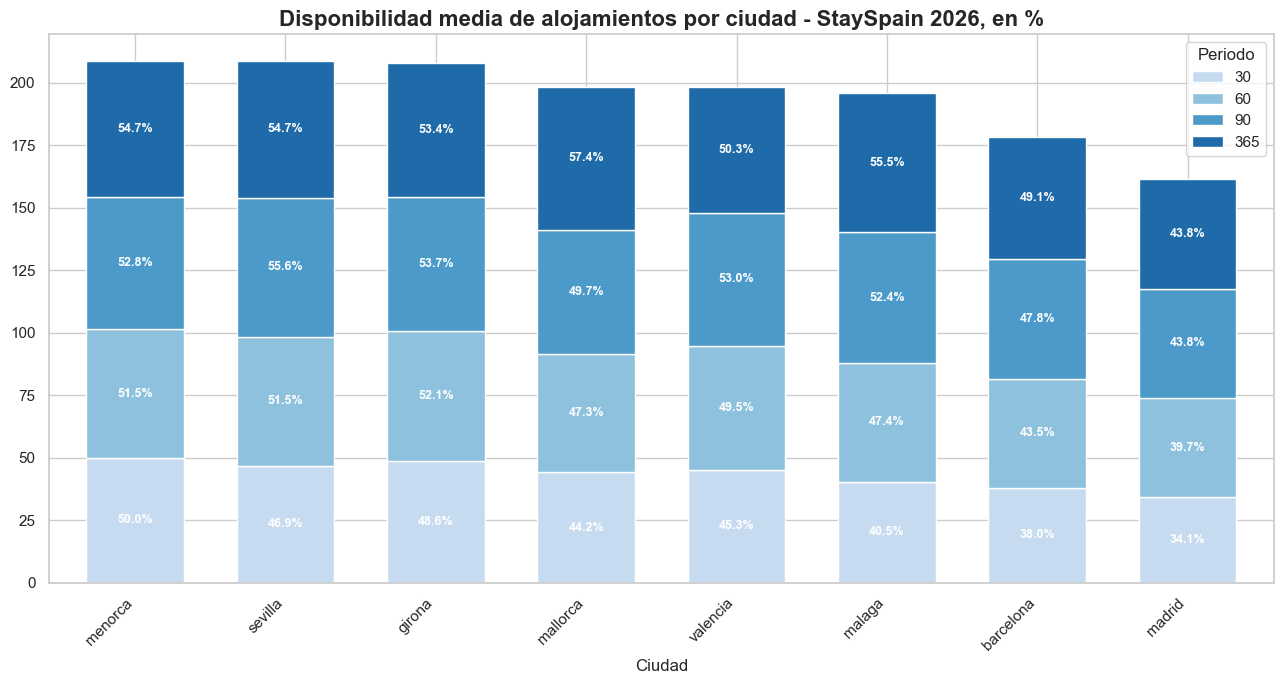

In [23]:
colores_periodo = [
    "#c6dbef",
    "#8ec1dd",
    "#4c9ac9",
    "#1f6aa8",
]

ax = tabla_grafico_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7),
    color=colores_periodo,
    width=0.65,
)

for contenedor in ax.containers:
    etiquetas = []

    for barra in contenedor:
        valor = barra.get_height()
        etiqueta = f"{valor:.1f}%" if valor > 0 else ""
        etiquetas.append(etiqueta)

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Disponibilidad media de alojamientos por ciudad - "
    "StaySpain 2026, en %",
    fontsize=16,
    fontweight="bold",
)
ax.set_xlabel("Ciudad")
ax.legend(title="Periodo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ruta_grafico_pct = ruta_resultados / "disponibilidad_media_pct_ciudad.png"
plt.savefig(ruta_grafico_pct, dpi=150, bbox_inches="tight")
plt.show()

## 9. Gráfico 2: disponibilidad media en días

Este gr?fico muestra cada plazo por separado para facilitar la lectura de los
días medios disponibles por ciudad.

C:\Users\giorg\AppData\Local\Temp\ipykernel_10080\3021944506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\giorg\AppData\Local\Temp\ipykernel_10080\3021944506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\giorg\AppData\Local\Temp\ipykernel_10080\3021944506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\giorg\AppData\Local\Temp\ipykernel_10080\3021944506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

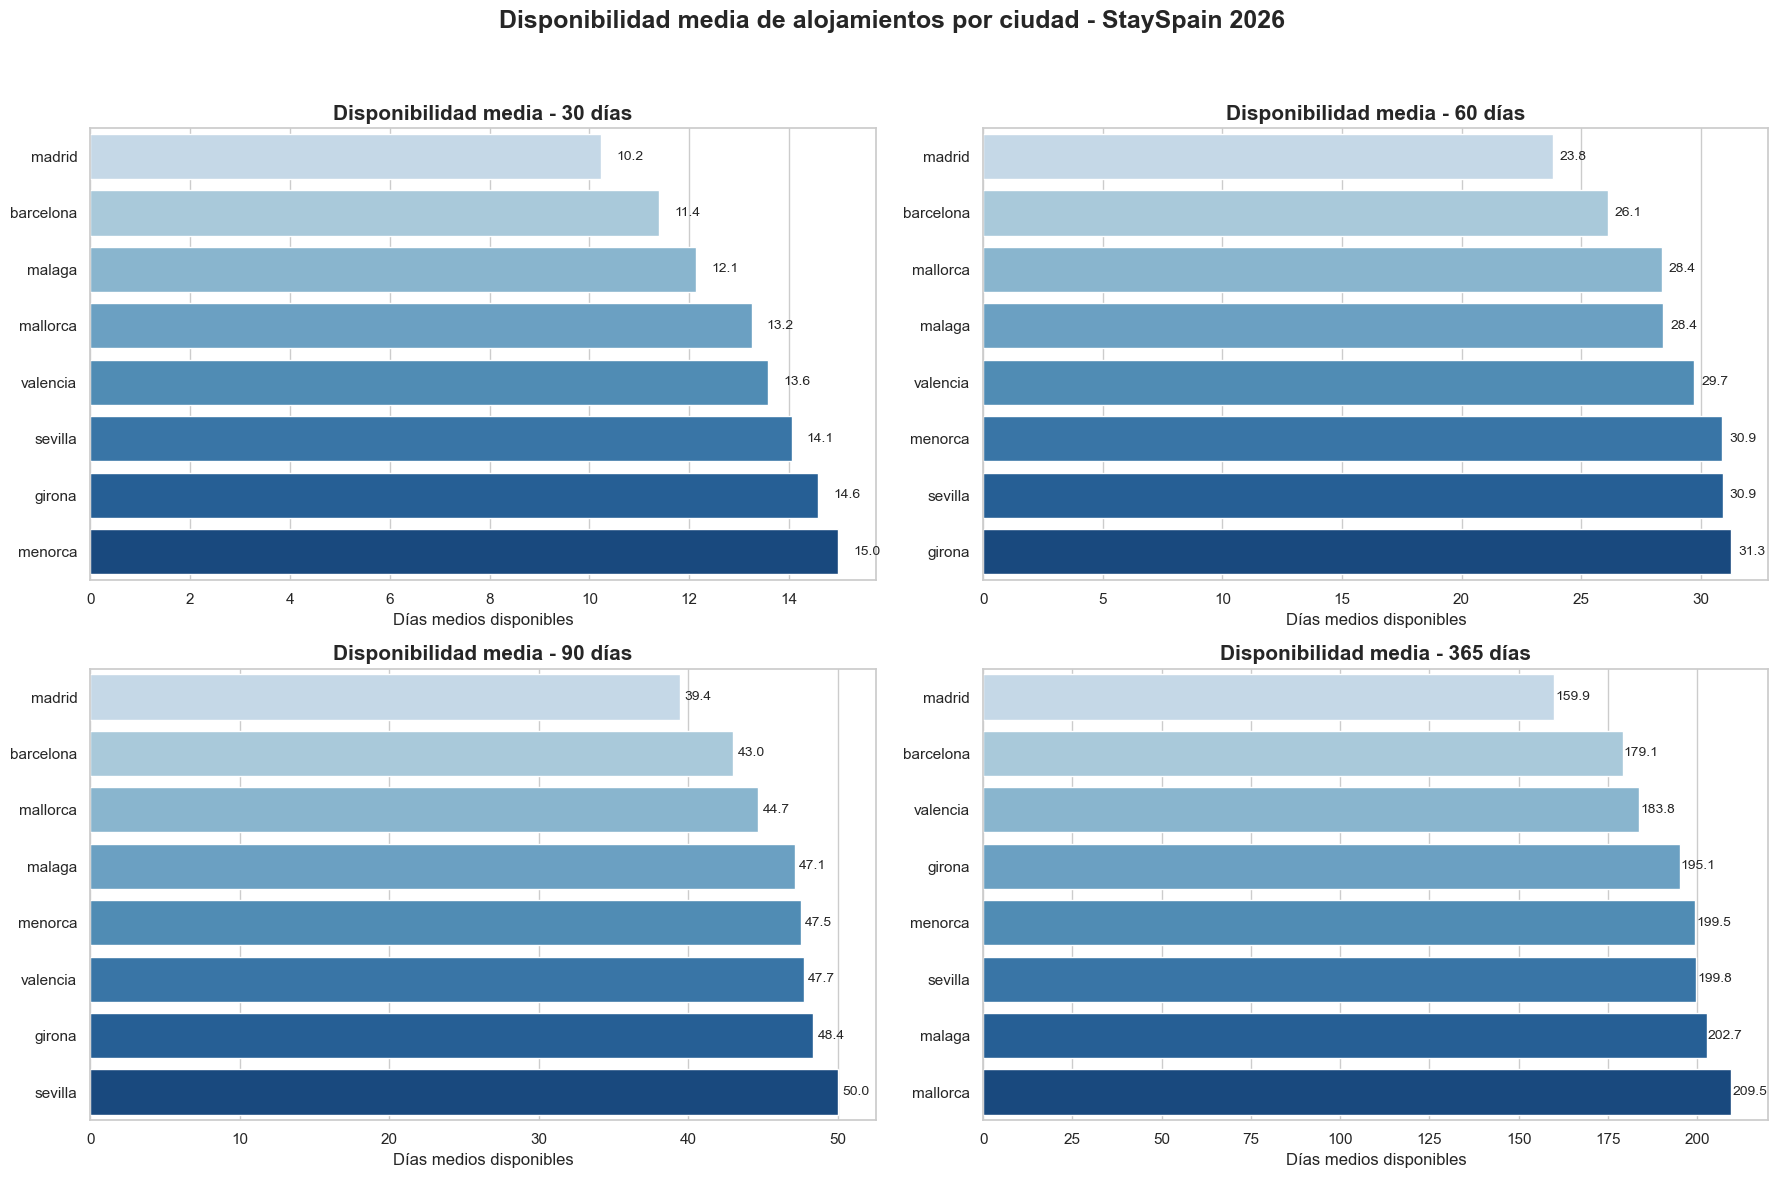

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
periodos_orden = [30, 60, 90, 365]

for periodo, ax in zip(periodos_orden, axes.flat):
    datos = resumen[resumen["periodo"] == periodo].copy()
    datos = datos.sort_values("promedio_dias")

    colores = sns.color_palette("Blues", n_colors=len(datos) + 2)[2:]

    sns.barplot(
        data=datos,
        x="promedio_dias",
        y="city",
        ax=ax,
        palette=colores,
    )

    for indice, fila in enumerate(datos.itertuples()):
        ax.text(
            fila.promedio_dias + 0.3,
            indice,
            f"{fila.promedio_dias:.1f}",
            va="center",
            fontsize=10,
        )

    ax.set_title(
        f"Disponibilidad media - {periodo} días",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Días medios disponibles")
    ax.set_ylabel("")

fig.suptitle(
    "Disponibilidad media de alojamientos por ciudad - StaySpain 2026",
    fontsize=18,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

ruta_grafico_dias = ruta_resultados / "disponibilidad_media_por_ciudad.png"
plt.savefig(ruta_grafico_dias, dpi=150, bbox_inches="tight")
plt.show()

## 10. Guardar resultados

Se guardan las tablas principales para que puedan usarse en la presentaci?n o
en otros notebooks.

In [17]:
ruta_resumen = ruta_resultados / "disponibilidad_resumen_ciudad_periodo.csv"
ruta_totales = ruta_resultados / "disponibilidad_total_por_ciudad.csv"
ruta_test = ruta_resultados / "disponibilidad_test_promedio.csv"

total_por_ciudad.to_csv(ruta_totales, index=False, encoding="utf-8-sig")
resumen.to_csv(ruta_resumen, index=False, encoding="utf-8-sig")
resultado_test_ciudad.to_csv(ruta_test, index=False, encoding="utf-8-sig")

print("Archivos generados en la carpeta results.")

Archivos generados en la carpeta results.


## 11. Respuesta de negocio

La disponibilidad media cambia según la ciudad y el plazo analizado. Para una
comparaci?n justa entre 30, 60, 90 y 365 d?as se usa el porcentaje medio de
disponibilidad.

El test ANOVA permite validar si las diferencias entre los cuatro plazos son
estad?sticamente significativas. Si `p_valor` es menor que 0.05, se rechaza la
hip?tesis de igualdad de medias y se concluye que existen diferencias
significativas entre los plazos.

In [22]:
mejores_365 = resumen[resumen["periodo"] == 365].sort_values(
    "promedio_pct",
    ascending=False,
)

peores_365 = resumen[resumen["periodo"] == 365].sort_values(
    "promedio_pct",
    ascending=True,
)

print("Ciudad con mayor disponibilidad media a 365 días:")
print(mejores_365[["city", "promedio_dias", "promedio_pct"]].head(1))

print("Ciudad con menor disponibilidad media a 365 días:")
print(peores_365[["city", "promedio_dias", "promedio_pct"]].head(1))

print("Resultado global del test:")
print(resultado_global)

Ciudad con mayor disponibilidad media a 365 días:
        city  promedio_dias  promedio_pct
19  mallorca          209.5          57.4
Ciudad con menor disponibilidad media a 365 días:
      city  promedio_dias  promedio_pct
11  madrid         159.93         43.82
Resultado global del test:
                    test  estadistico_f   p_valor  diferencia_significativa
0  ANOVA por permutaci?n        81.3532  0.000999                      True
